
# Job Scam Ads — Dataset Tuning & Pattern Mining

## The Challenge

Job seekers are increasingly vulnerable to fraudulent postings. These scams are designed to look legitimate but hide red flags—missing information, unusual language, contact methods that avoid formal channels, or financial demands tucked into the job description.


## The Journey

We start with raw job ads labeled as legitimate or fraudulent. Through this analysis, we'll:

1. **Build a signal library** — Extract structural and linguistic features that don't rely on keyword lists (which scammers can easily work around)
2. **Rank signals by power** — Which indicators most strongly separate fraud from legitimate postings?
3. **Discover feature combinations** — When signals appear together, how much more suspicious does a post become?
4. **Understand language patterns** — What words and phrases are fraud red flags? What makes legit jobs distinctive?
5. **Segment fraud types** — Identify scam-like posts that use conversion tactics (fast contact, money mentions, credibility shortcuts)
6. **Find scam families** — Group similar scams to understand recurring schemes and families of fraud



## Dataset---


`DataSet.csv`

## Preparation: Load Tools & Ground Rules

Let's start by bringing in the tools we'll need—libraries for data handling, text processing, and pattern discovery.

In [4]:

import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans

pd.set_option("display.max_colwidth", 140)


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Loading URL Shortener and Email Blocklist


URL Shortener Domains: A set of domains commonly used for URL shortening services, loaded from url_shorterner.rtf.
Disposable Email Domains: A blocklist of domains known for providing temporary or disposable email addresses, loaded from disposable_email_blocklist.txt.

These lists will be used to identify suspicious patterns in the dataset. The following code cell loads these resources and prepares the necessary regular expressions for text processing.

In [5]:
import re
from pathlib import Path

# Paths to your files
SHORTENER_RTF_PATH = "url_shorterner.rtf"         
DISPOSABLE_EMAIL_PATH = "disposable_email_blocklist.txt"

# Domain extractor (works even if the file has RTF markup)
DOMAIN_RE = re.compile(r"\b[a-z0-9-]+(?:\.[a-z0-9-]+)+\b", re.IGNORECASE)

def load_shortener_domains_from_rtf(path: str) -> set[str]:
    text = Path(path).read_text(errors="ignore")
    domains = {m.group(0).lower() for m in DOMAIN_RE.finditer(text)}
    # light filtering: keep things that look like real domains
    domains = {d.strip(").,;\"'") for d in domains if "." in d and len(d) >= 4}
    return domains

def load_domains_txt(path: str) -> set[str]:
    out = set()
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip().lower()
            if not line or line.startswith("#"):
                continue
            out.add(line)
    return out

SHORTENER_DOMAINS = load_shortener_domains_from_rtf(SHORTENER_RTF_PATH)
DISPOSABLE_EMAIL_DOMAINS = load_domains_txt(DISPOSABLE_EMAIL_PATH)

print("Shortener domains loaded:", len(SHORTENER_DOMAINS))
print("Disposable email domains loaded:", len(DISPOSABLE_EMAIL_DOMAINS))


Shortener domains loaded: 1479
Disposable email domains loaded: 5197


## Step 1: Load the Data & Understand the Baseline

- What's the fraud rate—our baseline expectation?

First, we bring in our dataset and establish what we're working with. We need to know:- How many legitimate vs fraudulent postings do we have?

In [6]:

MAIN_PATH = "DataSet.csv"
main = pd.read_csv(MAIN_PATH)

# Map 't'/'f' to 1/0
main["label"] = (main["fraudulent"].astype(str).str.lower() == "t").astype(int)

print("Shape:", main.shape)
print("Fraud rate:", main["label"].mean())
display(main.head(3))



Shape: (17880, 19)
Fraud rate: 0.04843400447427293


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset,label
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and ...","<p>Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curated recipe hub, is currently interv...",<ul>\r\n<li>Experience with content management systems a major plus (any blogging counts!)</li>\r\n<li>Familiar with the Food52 editoria...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Production Service.</h3>\r\n<p>90 Seconds is the worlds Cloud Video Production Service enabling b...",<p>Organised - Focused - Vibrant - Awesome!<br><br>Do you have a passion for customer service? Slick typing skills? Maybe Account Manage...,"<p><b>What we expect from you:</b></p>\r\n<p>Your key responsibility will be to communicate with the client, 90 Seconds team and freelan...",<h3><b>What you will get from us</b></h3>\r\n<p>Through being part of the 90 Seconds team you will gain:</p>\r\n<ul>\r\n<li>experience w...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,"<h3></h3>\r\n<p>Valor Services provides Workforce Solutions that meet the needs of companies across the Private Sector, with a special f...","<p>Our client, located in Houston, is actively seeking an experienced Commissioning Machinery Assistant that possesses strong supervisor...",<ul>\r\n<li>Implement pre-commissioning and commissioning procedures for rotary equipment.</li>\r\n<li>Execute all activities with subco...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f,0



## Step 2: Unify & Clean the Text

Job postings have multiple text fields: the title, company profile, job description, requirements, and benefits. The real story is hidden across all of them.

**What we do:** Combine all text into one field so we can read the complete job ad as a cohesive document. Then, we apply *lightweight* cleaning:
- Remove HTML formatting noise (tags, entities)
- Standardize URLs so they don't distract from real content
- Catch messaging apps (Telegram, WhatsApp) which are red flags for avoiding formal contact
- Normalize spacing and capitalization


No aggressive stopword removal, no stemming—we want to preserve the actual language patterns that distinguish scams from legitimate jobs.

In [7]:

TEXT_COLS = ["title", "company_profile", "description", "requirements", "benefits"]

def safe_str(x):
    return "" if pd.isna(x) else str(x)

HTML_TAG_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(
    r"(https?://\S+|www\.\S+|#url_[A-Za-z0-9]+#?)",
    re.IGNORECASE
)
TELEGRAM_RE = re.compile(r"@[A-Za-z0-9_]{5,32}")
WHATSAPP_RE = re.compile(r"(wa\.me/[\d+]+|api\.whatsapp\.com/send\S*|t\.me/\S+)", re.IGNORECASE)


def clean_text(s: str) -> str:
    s = "" if s is None else str(s)
    s = html.unescape(s)
    s = re.sub(HTML_TAG_RE, " ", s)
    s = re.sub(WHATSAPP_RE, " <whatsapp> ", s) 
    s = re.sub(URL_RE, " <url> ", s)
    s = re.sub(TELEGRAM_RE, " <telegram> ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s.lower()

main["combined_text_raw"] = main[TEXT_COLS].apply(lambda row: " \n ".join(safe_str(v) for v in row), axis=1)
main["combined_text"] = main["combined_text_raw"].apply(clean_text)

display(main[["title", "combined_text"]].head(2))


,title,combined_text
0,Marketing Intern,"marketing intern we're food52, and we've created a groundbreaking and award-winning cooking site. we support, connect, and celebrate hom..."
1,Customer Service - Cloud Video Production,"customer service - cloud video production 90 seconds, the worlds cloud video production service. 90 seconds is the worlds cloud video pr..."



## Step 3: First Clues—Structure & Style

Before we dive into words, let's look at *how* the content is presented. Scammers often leave structural clues:

- **Length**: Do fraudulent posts tend to be shorter? (Maybe they provide less detail because they're fabricated)
- **Digit density**: How many numbers appear? (Salary framing, account numbers, or obfuscated fee language?)
- **URL presence**: How often do they include external links? (Legitimate jobs link to company sites; scams might link to fake applications)


These surface-level features often reveal surprising differences between the two groups.

In [8]:

def add_basic_style_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    t = df["combined_text"]
    df["len_chars"] = t.str.len()
    df["len_words"] = t.str.split().apply(len)
    df["num_digits"] = t.str.count(r"\d")
    df["has_url"] = t.str.contains(r"<url>", regex=False).astype(int)
    df["digit_ratio"] = df["num_digits"] / df["len_chars"].clip(lower=1)
    return df

main_f = add_basic_style_features(main)

def summarize(group_df, name):
    s = pd.Series({
        "rows": len(group_df),
        "avg_words": group_df["len_words"].mean(),
        "avg_chars": group_df["len_chars"].mean(),
        "pct_has_url": group_df["has_url"].mean(),
        "avg_digit_ratio": group_df["digit_ratio"].mean(),
    })
    print(name)
    display(s)

summarize(main_f[main_f["label"]==0], "Main legit")
summarize(main_f[main_f["label"]==1], "Main fraud")


Main legit


rows               17014.000000
avg_words            398.872693
avg_chars           2657.885330
pct_has_url            0.314682
avg_digit_ratio        0.006486
dtype: float64

Main fraud


rows                866.000000
avg_words           297.609700
avg_chars          2042.635104
pct_has_url           0.308314
avg_digit_ratio       0.013566
dtype: float64


### Visualizing the Differences

We use cumulative distribution plots (CDFs) because they show us the *shape* of differences without being fooled by the fact that there are more legitimate jobs than fraudulent ones.
- **CDF**: If fraud posts tend to be shorter, their CDF curve will shift left

- **Rate plots**: For yes/no features, we simply compare percentages (e.g., "fraud has URLs in 45% of cases, legit in 8%")

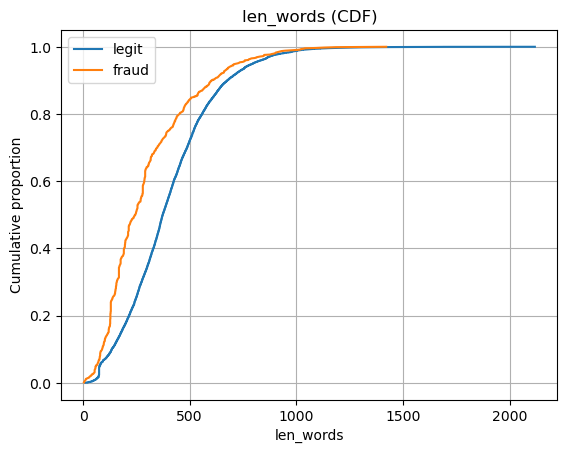

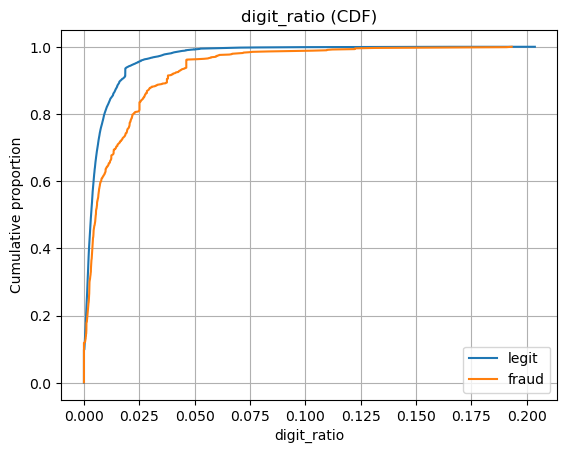

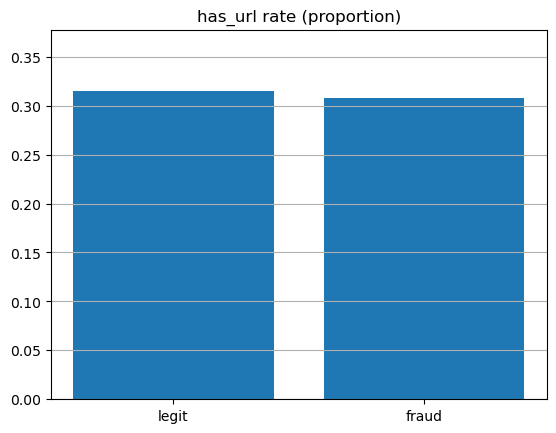

In [9]:

def plot_cdf(feature):
    plt.figure()
    for data, name in [
        (main_f.loc[main_f["label"]==0, feature], "legit"),
        (main_f.loc[main_f["label"]==1, feature], "fraud"),
    ]:
        x = np.sort(data.dropna().values)
        y = np.arange(1, len(x) + 1) / len(x)
        plt.plot(x, y, label=name)
    plt.title(f"{feature} (CDF)")
    plt.xlabel(feature)
    plt.ylabel("Cumulative proportion")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_binary_rate(feature):
    rates = {
        "legit": main_f.loc[main_f["label"]==0, feature].mean(),
        "fraud": main_f.loc[main_f["label"]==1, feature].mean(),
    }
    plt.figure()
    plt.bar(list(rates.keys()), list(rates.values()))
    plt.title(f"{feature} rate (proportion)")
    ymax = max(rates.values()) * 1.2
    plt.ylim(0, max(ymax, 0.01))
    plt.grid(axis="y")
    plt.show()

plot_cdf("len_words")
plot_cdf("digit_ratio")
plot_binary_rate("has_url")



## Step 4: Build a Feature Library

Now we move beyond surface-level metrics to build a *comprehensive feature library*. Think of features as "signals" or "red flags." Each signal reveals something about how the post was constructed.

**Completeness Signals** — Does the post feel professionally assembled?
- Missing company profile (legitimate companies usually fill this out)
- Missing or sparse job description
- How many text fields are blank?

**Structure Signals** — How is the content laid out?
- Text length: word/character counts
- Digit density: how many numbers appear?
- URL presence: external links included?
- Unusual patterns: very short posts, unusually high number density

**Extraction Signals** — What specific red-flag language appears?
- Email addresses (for official contact vs informal workarounds)
- Phone numbers
- Money or salary references
- Payment frequency language ("per hour," "weekly," etc.)
- Implausible salary amounts ( — e.g., $10,000/day)
- Telegram/WhatsApp handles ( — informal channels that bypass oversight)
- Phrases suggesting upfront fees ( — "registration fee," "deposit required," etc.)

**Metadata Flags** — What did the original data collectors note?
- Telecommuting allowed?
- Company logo present?
- Posting contains questions (suggests engagement)?

**Convenience Combinations** — Flags we create for easy analysis
- Has *any* contact method (email OR phone)?
- High digit ratio (unusual density of numbers)?
- Unusually short text?

This library is *generative*, not *predictive*—it's designed to reveal patterns, not to output a score.

In [ ]:


# Core extractors
EMAIL_RE = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")
EMAIL_DOMAIN_RE = re.compile(r"@([\w\.-]+\.\w+)\b")
PHONE_RE = re.compile(r"(\+?\d[\d\s\-\(\)]{7,}\d)")
MONEY_RE = re.compile(r"(\bsgd\b|\bs\$\b|\$)\s*[\d,]+(\.\d+)?", re.IGNORECASE)
PAYFREQ_RE = re.compile(r"\b(per\s*(hour|hr|day|week|month)|hourly|daily|weekly|monthly)\b", re.IGNORECASE)

# Telegram/WhatsApp pivots 
TELEGRAM_LINK_RE = re.compile(r"(t\.me/|telegram\.me/)", re.IGNORECASE)
WHATSAPP_LINK_RE = re.compile(r"(wa\.me/|api\.whatsapp\.com/|chat\.whatsapp\.com/)", re.IGNORECASE)

# Handle-like patterns 
TELEGRAM_HANDLE_RE = re.compile(r"@[A-Za-z0-9_]{5,32}")  # Telegram usernames
WHATSAPP_WORD_RE = re.compile(r"\bwhats\s*app\b|\bwhatsapp\b", re.IGNORECASE)
TELEGRAM_WORD_RE = re.compile(r"\btelegram\b|\btg\b", re.IGNORECASE)

# Fee / deposit style phrases 
FEE_OBFUSCATION_RE = re.compile(
    r"\b(deposit required|registration fee|training (fee|material|kit)|starter kit|security deposit|admin fee)\b",
    re.IGNORECASE
)

# Salary heuristic
SALARY_RE = re.compile(r"\$\s*([\d,]+)", re.IGNORECASE)

def count_regex(text, regex):
    return len(regex.findall(text or ""))

def tf_to_int(x):
    x = str(x).lower()
    if x == "t": return 1
    if x == "f": return 0
    return np.nan

# --- External-list helpers ---
# Requires DOMAIN_RE, SHORTENER_DOMAINS, DISPOSABLE_EMAIL_DOMAINS
def extract_domains(text: str) -> list[str]:
    """
    Extract domain-like tokens from RAW text.
    DOMAIN_RE should be defined in your 'load lists' cell.
    """
    if not text:
        return []
    return [m.group(0).lower().strip(").,;\"'") for m in DOMAIN_RE.finditer(text)]

def has_shortener_domain(raw_text: str) -> int:
    domains = extract_domains(raw_text)
    return int(any(d in SHORTENER_DOMAINS for d in domains))

def has_disposable_email(raw_text: str) -> int:
    domains = [d.lower() for d in EMAIL_DOMAIN_RE.findall(raw_text or "")]
    return int(any(d in DISPOSABLE_EMAIL_DOMAINS for d in domains))

def has_telegram_pivot(raw_text: str) -> int:
    s = raw_text or ""
    return int(bool(
        TELEGRAM_LINK_RE.search(s) or
        TELEGRAM_HANDLE_RE.search(s) or
        TELEGRAM_WORD_RE.search(s)
    ))

def has_whatsapp_pivot(raw_text: str) -> int:
    s = raw_text or ""
    return int(bool(
        WHATSAPP_LINK_RE.search(s) or
        WHATSAPP_WORD_RE.search(s)
    ))

def implausible_salary(text: str) -> int:
    """
    Flag if any extracted dollar amount exceeds a rough 'too-good-to-be-true' threshold.
    Note: this dataset is not SG-specific; tune thresholds for SG using MOM benchmarks if needed.
    """
    hits = []
    for m in SALARY_RE.findall(text or ""):
        try:
            hits.append(int(m.replace(",", "")))
        except:
            pass
    return int(any(h > 1500 for h in hits))


def feature_bank(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)

    # Use both cleaned text (for <url> token etc.) and raw text (for domain extraction)
    t = df["combined_text"].fillna("").astype(str)
    raw = df["combined_text_raw"].fillna("").astype(str)

    # -------------------------
    # Missingness / completeness
    # -------------------------
    for c in TEXT_COLS:
        out[f"missing_{c}"] = df[c].isna().astype(int)
    out["completeness_score"] = 1.0 - out[[f"missing_{c}" for c in TEXT_COLS]].mean(axis=1)

    # -------------------------
    # Structure signals
    # -------------------------
    out["len_chars"] = t.str.len()
    out["len_words"] = t.str.split().apply(len)
    out["num_digits"] = t.str.count(r"\d")
    out["has_url"] = t.str.contains("<url>", regex=False).astype(int)
    out["num_urls"] = t.str.count(r"<url>")
    out["digit_ratio"] = out["num_digits"] / out["len_chars"].clip(lower=1)

    # -------------------------
    # Extraction signals (cleaned text)
    # -------------------------
    out["num_emails"] = t.apply(lambda s: count_regex(s, EMAIL_RE))
    out["num_phones"] = t.apply(lambda s: count_regex(s, PHONE_RE))
    out["num_money_mentions"] = t.apply(lambda s: count_regex(s, MONEY_RE))
    out["has_pay_frequency"] = t.apply(lambda s: int(bool(PAYFREQ_RE.search(s or ""))))
    out["implausible_salary"] = t.apply(implausible_salary)
    out["has_fee_phrase"] = t.apply(lambda s: int(bool(FEE_OBFUSCATION_RE.search(s or ""))))

    # -------------------------
    # External-list enriched signals (RAW text)
    # -------------------------
    out["has_shortener_domain"] = raw.apply(has_shortener_domain)
    out["has_disposable_email"] = raw.apply(has_disposable_email)

    # Messaging app pivots (prefer RAW because domains/handles appear there)
    out["has_telegram"] = raw.apply(has_telegram_pivot)
    out["has_whatsapp"] = raw.apply(has_whatsapp_pivot)

    # -------------------------
    # Metadata flags
    # -------------------------
    out["telecommuting"] = df["telecommuting"].apply(tf_to_int).fillna(0).astype(int)
    out["has_company_logo"] = df["has_company_logo"].apply(tf_to_int).fillna(0).astype(int)
    out["has_questions"] = df["has_questions"].apply(tf_to_int).fillna(0).astype(int)

    # -------------------------
    # Convenience flags
    # -------------------------
    out["has_contact"] = ((out["num_emails"] > 0) | (out["num_phones"] > 0)).astype(int)
    out["high_digit_ratio"] = (out["digit_ratio"] >= out["digit_ratio"].quantile(0.90)).astype(int)
    out["short_text"] = (out["len_words"] <= out["len_words"].quantile(0.10)).astype(int)

    return out


X = feature_bank(main)
display(X.head(3))



,missing_title,missing_company_profile,missing_description,missing_requirements,missing_benefits,completeness_score,len_chars,len_words,num_digits,has_url,...,has_shortener_domain,has_disposable_email,has_telegram,has_whatsapp,telecommuting,has_company_logo,has_questions,has_contact,high_digit_ratio,short_text
0,0,0,0,0,1,0.8,2677,402,14,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,1.0,5717,935,88,1,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,1,0.8,2649,374,0,0,...,0,0,0,0,0,1,0,0,0,0


Sanity checks:
has_shortener_domain hits: 2
has_disposable_email hits: 0
has_telegram hits: 165
has_whatsapp hits: 57


## Step 5: Rank the Signals—Which Matter Most?

Now that we have a library of signals, we ask: **Which ones actually separate fraud from legitimate jobs?**

We use two ranking methods to measure signal power:

**Odds Ratio** — For binary yes/no signals
- Compares how much more likely a fraudulent post is to have a signal compared to legitimate ones
- Odds Ratio = 1 → signal is equally common in both groups (not useful)
- Odds Ratio = 5 → fraud is 5x more likely to have this signal (powerful!)
- Odds Ratio = 0.2 → fraud is *less* likely to have it (opposite direction indicator)

**Mutual Information** — For all types of signals
- A broader measure that captures how much knowing a feature's value reduces uncertainty about whether a post is fraud
- Works for both binary and continuous features
- Higher scores mean the feature tells us more about fraud likelihood

The highest-ranked signals become our most diagnostic clues—the ones that separate scams from real jobs most reliably.

In [11]:

y = main["label"].values

# Odds ratio on binary features
bin_cols = [c for c in X.columns if set(X[c].dropna().unique()).issubset({0, 1})]

def odds_ratio(col):
    feat = X[col].values.astype(int)
    a = np.sum((y==1) & (feat==1))
    b = np.sum((y==0) & (feat==1))
    c = np.sum((y==1) & (feat==0))
    d = np.sum((y==0) & (feat==0))
    a,b,c,d = a+0.5, b+0.5, c+0.5, d+0.5
    return (a/b) / (c/d)

MIN_SUPPORT = 0.01  # ~179 rows minimum; raise to 0.025 for primary blocking rules
rows = []
for col in bin_cols:
    support = X[col].mean()
    if support < MIN_SUPPORT:
        continue
    rows.append((col, odds_ratio(col), X.loc[y==1, col].mean(), X.loc[y==0, col].mean(), support))

or_df = pd.DataFrame(rows, columns=["feature", "odds_ratio", "p(f=1|fraud)", "p(f=1|legit)", "support"]).sort_values("odds_ratio", ascending=False)
display(or_df.head(20))  

# Mutual information
X_mi = X.fillna(0)
mi = mutual_info_classif(X_mi.values, y, discrete_features=False, random_state=42)
mi_df = pd.DataFrame({"feature": X_mi.columns, "mutual_info": mi}).sort_values("mutual_info", ascending=False)
display(mi_df.head(20))


,feature,odds_ratio,p(f=1|fraud),p(f=1|legit),support
0,missing_company_profile,11.039675,0.677829,0.159927,0.185011
5,implausible_salary,7.342794,0.125866,0.019278,0.024441
10,high_digit_ratio,3.660652,0.269053,0.091454,0.100056
11,short_text,3.041076,0.240185,0.094275,0.101342
6,telecommuting,1.863565,0.073903,0.041319,0.042897
4,has_pay_frequency,1.310806,0.374134,0.313330,0.316275
1,missing_requirements,1.228013,0.176674,0.149054,0.150391
9,has_contact,1.208867,0.054273,0.045727,0.046141
2,missing_benefits,1.075656,0.419169,0.401610,0.402461
3,has_url,0.971701,0.308314,0.314682,0.314374


,feature,mutual_info
6,len_chars,0.035681
11,digit_ratio,0.032744
23,has_company_logo,0.031144
1,missing_company_profile,0.030899
7,len_words,0.026329
8,num_digits,0.013579
5,completeness_score,0.010781
14,num_money_mentions,0.009043
24,has_questions,0.006730
26,high_digit_ratio,0.005928


## Step 6: Combinations Create Conviction

Single signals are useful, but scammers are clever. A single red flag might be innocent (maybe a startup forgot their logo), but *multiple flags together* paint a dramatically clearer picture.

Here we ask: **When signals appear together, how much do they amplify suspicion?**

We look at pairs of high-ranked signals and measure three things:

- **Support**: How often does this combination appear in the dataset? (We ignore rare combinations that appear in <2.5% of posts)
- **Fraud Rate**: Of all posts with both signals together, what fraction are actually fraudulent?
- **Lift**: How much does this combination *increase* the fraud rate above our baseline? A lift of 2.0x means posts with both signals are twice as likely to be fraud compared to the average post.

High-lift combinations become our "red flag bundles"—pattern signatures that, when detected together, warrant close human review.

In [12]:

base_rate = y.mean()
top_bin = or_df.loc[or_df["feature"] != "telecommuting", "feature"].head(25).tolist()


pair_rows = []
for a, b in combinations(top_bin, 2):
    ab = (X[a].values.astype(int) & X[b].values.astype(int))
    support = ab.mean()
    if support < 0.025:
        continue
    fraud_rate_ab = y[ab==1].mean()
    lift = fraud_rate_ab / base_rate if base_rate > 0 else np.nan
    pair_rows.append((a, b, support, fraud_rate_ab, lift))

pair_df = pd.DataFrame(pair_rows, columns=["A", "B", "support", "fraud_rate_given_AB", "lift_vs_base"]).sort_values("lift_vs_base", ascending=False)
display(pair_df.head(25))


,A,B,support,fraud_rate_given_AB,lift_vs_base
0,missing_company_profile,high_digit_ratio,0.025000,0.398210,8.221709
2,missing_company_profile,has_pay_frequency,0.043568,0.286264,5.910402
1,missing_company_profile,short_text,0.044463,0.250314,5.168155
5,missing_company_profile,has_url,0.037864,0.243722,5.032049
3,missing_company_profile,missing_requirements,0.042114,0.193891,4.003202
17,short_text,missing_benefits,0.040772,0.193416,3.993385
16,short_text,missing_requirements,0.026063,0.178112,3.677408
4,missing_company_profile,missing_benefits,0.093456,0.175943,3.632624
9,high_digit_ratio,has_pay_frequency,0.048043,0.152503,3.148674
11,high_digit_ratio,missing_benefits,0.025000,0.149888,3.094688


## Step 7: The Words Tell the Story

Beyond structure and signals, the actual *words* matter. Scammers develop behavioral patterns in their language over time, and legitimate employers have their own linguistic fingerprints.

**What we do:**
Extract all single words and 2-word phrases from posts and rank them by:
- **Fraud signature**: Phrases that appear much more often in fraudulent posts than legitimate ones
- **Legitimacy signature**: Phrases that legitimate employers use but scammers avoid

**Why this matters:** 
This gives us a readable dictionary of linguistic red flags ("hire immediately," "easy money," etc.) and legitimate job markers ("experienced," "team environment," etc.). Unlike keyword-matching systems scammers can game, these patterns reveal deeper behavioral differences.

In [13]:

texts = main["combined_text"].values
y = main["label"].values

wvec = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=5,
    stop_words="english",
    max_features=200000
)
Xw = wvec.fit_transform(texts)

fraud_idx = (y == 1)
legit_idx = (y == 0)

fraud_mean = Xw[fraud_idx].mean(axis=0).A1
legit_mean = Xw[legit_idx].mean(axis=0).A1
diff = fraud_mean - legit_mean

terms = np.array(wvec.get_feature_names_out())
top_pos = np.argsort(diff)[-40:][::-1]
top_neg = np.argsort(diff)[:40]

print("Top WORD n-grams more prevalent in FRAUD:")
for i in top_pos[:25]:
    print(terms[i], diff[i])

print("\nTop WORD n-grams more prevalent in LEGIT:")
for i in top_neg[:25]:
    print(terms[i], diff[i])


Top WORD n-grams more prevalent in FRAUD:
data entry 0.020508749137590557
entry 0.0190033452057548
earn 0.012477065614903589
aker 0.011045111989692187
administrative 0.010847799160442997
home 0.010844828895246024
aker solutions 0.010481843595493512
work home 0.009749850827587125
typing 0.00948545602229996
assistant 0.009054411929256496
oil 0.008836130158026758
computer internet 0.007910111576189796
position 0.007880092528731487
internet 0.007813813800731245
gas 0.007721148229326107
oil gas 0.0074874742080113035
cash 0.007394579397826181
administrative assistant 0.0073802556256216765
internet access 0.007360884012688898
subsea 0.007320607566238937
data 0.006999432449005716
clerk 0.006927542412386969
computer 0.006554855440950008
clerical 0.006548039544250652
000 0.00633631947970337

Top WORD n-grams more prevalent in LEGIT:
web -0.009452344635138162
team -0.009342929677961423
marketing -0.009302095356476466
abroad -0.008085515443212272
digital -0.007656330374465035
media -0.007451682366

## Step 8: Fraud Comes in Types

Not all fraud is the same. Some fraudulent posts are simply illegitimate, but others are **scam-like**—designed to quickly convert vulnerable job seekers into victims.

**Scam-like posts exhibit conversion mechanics:**
- **Urgency & money signals**: References to payment, salary, or opportunities for quick transaction
- **Alternative contact routes**: Email, phone, Telegram, WhatsApp—anything to move the conversation away from the official job board where reviews exist
- **Low credibility shortcuts**: Missing company details, unusually short descriptions, high number density (obfuscated financial language)

**Our hypothesis:** When a fraudulent post *combines* conversion mechanics (contact + money framing) *with* low credibility signals (missing info + suspicious structure), it's likely a scam—not just generic fraud.

We segment the fraudulent posts in our dataset to isolate this scam-like subset, which we'll then cluster to find recurring patterns.

In [14]:


fraud_df = main.loc[main["label"] == 1].copy()

money_or_contact = (
    (X.loc[fraud_df.index, "num_money_mentions"] > 0) |
    (X.loc[fraud_df.index, "has_contact"] == 1) |
    (X.loc[fraud_df.index, "has_telegram"] == 1) |
    (X.loc[fraud_df.index, "has_whatsapp"] == 1)
)

low_credibility_or_bait = (
    (X.loc[fraud_df.index, "missing_company_profile"] == 1) |
    (X.loc[fraud_df.index, "short_text"] == 1) |
    (X.loc[fraud_df.index, "high_digit_ratio"] == 1)
)

scammy_mask = money_or_contact & low_credibility_or_bait

print("Fraud total:", len(fraud_df),
      "| Scam-like (strong) subset:", int(scammy_mask.sum()),
      f"({scammy_mask.mean():.1%} of fraud)")
scammy_fraud_texts = fraud_df.loc[scammy_mask, "combined_text"].values


Fraud total: 866 | Scam-like (strong) subset: 213 (24.6% of fraud)


## Step 9: Identify Scam Families

The final piece of our forensic investigation: **How many distinct scam patterns exist in our dataset?**

We take the scam-like fraudulent posts and run unsupervised clustering on their character-level patterns (3-5 character n-grams). This groups similar-looking scams together, revealing:

- **How many distinct "scam families" operate** in job postings
- **What makes each family unique** — the distinctive words, phrases, and language patterns they favor
- **How prevalent each family is** — how many victims fall into each scam pattern
- **Example posts from each family** — actual text snippets showing what each family looks like

Think of it like a field guide to job scams. Each cluster is a "species" with recognizable traits—patterns that come back again and again. By understanding these families, we can better educate job seekers about what to watch for.

In [15]:

scammy_fraud_texts = pd.Series(scammy_fraud_texts).drop_duplicates().values
print("Scam-like fraud texts after de-dup:", len(scammy_fraud_texts))

fraud_vec = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=120000
)
fraud_X = fraud_vec.fit_transform(scammy_fraud_texts)

k = 13
km = KMeans(n_clusters=k, random_state=42, n_init="auto")
fraud_labels = km.fit_predict(fraud_X)

word_vec = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    stop_words="english",
    max_features=50000
)
fraud_word_X = word_vec.fit_transform(scammy_fraud_texts)
word_terms = np.array(word_vec.get_feature_names_out())

topn_terms = 15

for c in range(k):
    idx = np.where(fraud_labels == c)[0]
    print(f"\n=== Cluster {c} | size={len(idx)} ===")

    cluster_mean_word = fraud_word_X[idx].mean(axis=0).A1
    top_idx = np.argsort(cluster_mean_word)[-topn_terms:][::-1]
    print("Top word n-grams (descriptive):", ", ".join(word_terms[top_idx]))

    examples = scammy_fraud_texts[idx[:3]]
    for j, ex in enumerate(examples, 1):
        print(f"Example {j}:", ex[:300].replace("\n"," "))


Scam-like fraud texts after de-dup: 164

=== Cluster 0 | size=18 ===
Top word n-grams (descriptive): cash, start, experience required, zero start, start fee, required, zero, fee, day, required zero, time, perfect start, afternoon, afternoon night, work morning
Example 1: weekly cash jobs, hiring part time workers. weekly cash jobs, hiring part time workers. you can do it all from home, in your free time, at your own place. spend 30 minutes or 1 hours a day & get biggest cash. you can work in the morning, afternoon, or at night. perfect for everyone then start immedi
Example 2: cash in hand job (part-time staff needed) cash in hand job (part-time staff needed) you can do it all from home, in your free time, at your own place. spend 30 minutes or 1 hours a day & get biggest cash. you can work in the morning, afternoon, or at night. perfect for everyone then start immediatel
Example 3: part time staff needed, weekend cash job. part time staff needed, weekend cash job. you can do it all fr

## What We've Discovered: From Data to Action

**The journey we just took:** From raw job postings → structural signals → ranked indicators → linguistic patterns → scam family clusters.

### Key Takeaways

**1. Fraud is Detectable Without Keywords**
- Structure, completeness, language patterns, and contact methods reveal fraud as reliably as keyword matching—without the vulnerability to gaming.
- Scammers can change words; they can't change their operational behavior.

**2. Signals Compound**
- Single red flags are ambiguous. But when multiple signals appear together (missing company details + contact info + money framing), conviction rises dramatically.
- The highest-lift combinations represent "scam signatures"—patterns worth automating for real-time detection.

**3. Scam Families Have Fingerprints**
- We've identified distinct clusters—different scam "families" with recognizable traits. Some focus on credential theft, others on payment/commission scams, others on employment manipulation.
- Understanding these families helps us predict *how* a scam will unfold, not just *whether* it's a scam.

**4. Language is a Behavioral Signal**
- Legitimate employers and job scammers use different words not by accident, but by design. This linguistic gap is natural and measurable.
- Identifying fraud-signature phrases gives us readable, explainable red flags we can share with job seekers.

